# Word Embeddings: Live Demo

In this notebook, we'll explore word embeddings hands-on. We'll:
1. See why Bag of Words falls short
2. Load pre-trained GloVe word vectors
3. Explore word similarity
4. Do the famous **King - Man + Woman = Queen** arithmetic
5. Visualize word embeddings in 2D

## Setup

First, let's install and import what we need.

In [4]:
# Dependencies are managed by Pixi for this notebook project.
# If needed, update dependencies in pixi.toml and run: pixi install
print("Environment already provisioned via Pixi.")

Environment already provisioned via Pixi.


In [5]:
import numpy as np
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import scipy.linalg as sl
# Compatibility for newer SciPy builds where scipy.linalg.triu may be missing.
if not hasattr(sl, "triu"):
    sl.triu = np.triu
import gensim.downloader as api
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

print("All imports ready! ✅")

All imports ready! ✅


---
## Part 1: Why Bag of Words Falls Short

**Analogy:** Bag of Words is like describing a movie by listing which actors appear in it, but ignoring the plot, relationships, and emotions. You get *some* info, but you miss the meaning.

Let's see the problem with a simple example.

In [6]:
# Three sentences — two mean the same thing, one is different
sentences = [
    "The patient has a fever",          # Sentence A
    "The patient has a high temperature", # Sentence B (same meaning as A!)
    "The patient has a dog"              # Sentence C (very different meaning)
]

# Bag of Words: just count how many times each word appears
vectorizer = CountVectorizer()
bow_matrix = vectorizer.fit_transform(sentences)

print("Vocabulary:", vectorizer.get_feature_names_out())
print()
print("Bag of Words vectors:")
for i, sent in enumerate(sentences):
    print(f"  '{sent}'")
    print(f"   → {bow_matrix.toarray()[i]}")
    print()

Vocabulary: ['dog' 'fever' 'has' 'high' 'patient' 'temperature' 'the']

Bag of Words vectors:
  'The patient has a fever'
   → [0 1 1 0 1 0 1]

  'The patient has a high temperature'
   → [0 0 1 1 1 1 1]

  'The patient has a dog'
   → [1 0 1 0 1 0 1]



In [7]:
# Now let's measure similarity between sentences using cosine similarity
sim_AB = cosine_similarity(bow_matrix[0], bow_matrix[1])[0][0]
sim_AC = cosine_similarity(bow_matrix[0], bow_matrix[2])[0][0]
sim_BC = cosine_similarity(bow_matrix[1], bow_matrix[2])[0][0]

print("Cosine Similarity (BoW):")
print(f"  'fever' vs 'high temperature':  {sim_AB:.3f}")
print(f"  'fever' vs 'dog':               {sim_AC:.3f}")
print(f"  'high temperature' vs 'dog':    {sim_BC:.3f}")
print()
print("🤔 Notice: 'fever' and 'high temperature' should be VERY similar,")
print("   but BoW says 'fever' is just as close to 'dog' as to 'high temperature'!")
print("   That's because BoW doesn't understand that fever ≈ high temperature.")

Cosine Similarity (BoW):
  'fever' vs 'high temperature':  0.671
  'fever' vs 'dog':               0.750
  'high temperature' vs 'dog':    0.671

🤔 Notice: 'fever' and 'high temperature' should be VERY similar,
   but BoW says 'fever' is just as close to 'dog' as to 'high temperature'!
   That's because BoW doesn't understand that fever ≈ high temperature.


### The Problem with Bag of Words

| Limitation | What it means |
|---|---|
| No word meaning | "fever" and "temperature" are treated as completely unrelated |
| No word order | "dog bites man" = "man bites dog" |
| Sparse vectors | Mostly zeros — wasteful and hard for models to learn from |

**We need a smarter way to represent words — one that captures MEANING.**

That's where **word embeddings** come in!

---
## Part 2: Loading Pre-Trained GloVe Word Vectors

**What is GloVe?** GloVe (Global Vectors) learned word meanings by reading **6 billion words** from the internet (Wikipedia + news articles). It figured out that words appearing in similar contexts have similar meanings.

**Analogy:** Imagine you moved to a new city and wanted to figure out which restaurants are similar. You could look at which *people* go to the same restaurants — restaurants with overlapping customers are probably similar (both pizza places, both fancy, etc.). GloVe does the same thing: words that keep the same *company* (surrounding words) are probably similar.

We'll use 100-dimensional vectors — each word is represented by 100 numbers.

⏳ **This download takes 1-2 minutes the first time.**

In [8]:
# Load pre-trained GloVe vectors (100 dimensions, trained on 6B words)
# This downloads ~128MB the first time — grab some water! ☕
glove = api.load("glove-wiki-gigaword-100")

print(f"Loaded {len(glove)} word vectors!")
print(f"Each word is represented by {glove.vector_size} numbers")

[==================================================] 100.0% 128.1/128.1MB downloaded
Loaded 400000 word vectors!
Each word is represented by 100 numbers


In [9]:
# Let's peek at what a word vector looks like
word = "python"
vector = glove[word]

print(f"The word '{word}' is represented as a vector of {len(vector)} numbers:")
print(f"First 10 values: {vector[:10].round(3)}")
print(f"...")
print(f"Last 10 values:  {vector[-10:].round(3)}")
print()
print("These numbers don't mean anything individually —")
print("but TOGETHER they capture the meaning of the word!")

The word 'python' is represented as a vector of 100 numbers:
First 10 values: [ 0.249  0.683 -0.045 -1.384 -0.007  0.651 -0.34  -0.198 -0.339  0.267]
...
Last 10 values:  [ 0.457  0.61  -0.115  0.426  0.173 -0.8   -0.245 -0.609 -0.385 -0.48 ]

These numbers don't mean anything individually —
but TOGETHER they capture the meaning of the word!


---
## Part 3: Exploring Word Similarity

Now let's see if GloVe actually understands that words have similar meanings.

Remember our BoW problem? "fever" and "temperature" were treated as completely different. Let's see what GloVe thinks!

In [10]:
# Cosine similarity using word embeddings
# (1.0 = identical, 0.0 = unrelated, -1.0 = opposite)

pairs = [
    ("fever", "temperature"),   # Should be similar!
    ("fever", "dog"),           # Should be different
    ("doctor", "nurse"),        # Related professions
    ("doctor", "pizza"),        # Unrelated
    ("happy", "joyful"),        # Synonyms
    ("happy", "sad"),           # Opposites
]

print("Word Similarity (GloVe embeddings):")
print("-" * 45)
for word1, word2 in pairs:
    sim = glove.similarity(word1, word2)
    print(f"  {word1:12s} ↔ {word2:12s}  = {sim:.3f}")

Word Similarity (GloVe embeddings):
---------------------------------------------
  fever        ↔ temperature   = 0.322
  fever        ↔ dog           = 0.369
  doctor       ↔ nurse         = 0.752
  doctor       ↔ pizza         = 0.204
  happy        ↔ joyful        = 0.526
  happy        ↔ sad           = 0.680


In [11]:
# What words are most similar to "hospital"?
print("Words most similar to 'hospital':")
for word, score in glove.most_similar("hospital", topn=10):
    print(f"  {word:15s} ({score:.3f})")

Words most similar to 'hospital':
  clinic          (0.814)
  medical         (0.782)
  hospitals       (0.770)
  nursing         (0.715)
  hospitalized    (0.694)
  doctors         (0.693)
  psychiatric     (0.693)
  doctor          (0.690)
  nurse           (0.665)
  patients        (0.661)


In [12]:
# Try some more! What's similar to...
words_to_explore = ["machine", "learning", "california", "pizza"]

for w in words_to_explore:
    similar = glove.most_similar(w, topn=5)
    top_words = [word for word, _ in similar]
    print(f"  '{w}' → {top_words}")

  'machine' → ['machines', 'device', 'equipment', 'gun', 'guns']
  'learning' → ['teaching', 'knowledge', 'experience', 'skills', 'learn']
  'california' → ['texas', 'florida', 'oregon', 'arizona', 'calif.']
  'pizza' → ['sandwich', 'sandwiches', 'bread', 'pizzas', 'burger']


### 🧪 Which word doesn't belong?

GloVe can also figure out which word is the odd one out in a group — just like those SAT questions!

In [13]:
# Which word doesn't belong?
groups = [
    ["breakfast", "lunch", "dinner", "laptop"],
    ["doctor", "nurse", "surgeon", "bicycle"],
    ["python", "java", "javascript", "banana"],
]

for group in groups:
    odd = glove.doesnt_match(group)
    print(f"  {group} → odd one out: '{odd}'")

  ['breakfast', 'lunch', 'dinner', 'laptop'] → odd one out: 'laptop'
  ['doctor', 'nurse', 'surgeon', 'bicycle'] → odd one out: 'bicycle'
  ['python', 'java', 'javascript', 'banana'] → odd one out: 'banana'


---
## Part 4: Word Arithmetic — King - Man + Woman = ?

This is the mind-blowing part. Because word vectors capture *relationships*, you can actually do **math with words**.

**Analogy:** Think of it like GPS coordinates. If you know the "direction" from San Francisco to Los Angeles (south along the coast), you could apply that same direction starting from Seattle and end up near Portland. Word vectors work the same way — the "direction" from Man to Woman can be applied to King to get Queen.

The formula: **King - Man + Woman = ?**

Translation: "Take the concept of King, remove the 'maleness', add 'femaleness'"

In [14]:
# The famous word analogy: king - man + woman = ???
result = glove.most_similar(positive=["king", "woman"], negative=["man"], topn=5)

print("king - man + woman = ?")
print()
for word, score in result:
    marker = " 👑" if word == "queen" else ""
    print(f"  {word:15s} ({score:.3f}){marker}")

king - man + woman = ?

  queen           (0.770) 👑
  monarch         (0.684)
  throne          (0.676)
  daughter        (0.659)
  princess        (0.652)


In [15]:
# Let's try more analogies!
analogies = [
    # (word1, word2, word3) → word1 - word2 + word3 = ?
    # "word1 is to word2 as ? is to word3"
    ("paris", "france", "germany"),     # Capital city relationship
    ("bigger", "big", "small"),         # Comparative relationship
    ("walking", "walk", "swim"),        # Tense relationship
    ("doctor", "hospital", "school"),   # Workplace relationship
]

print("Word Analogies:")
print("=" * 55)
for w1, w2, w3 in analogies:
    result = glove.most_similar(positive=[w1, w3], negative=[w2], topn=1)
    answer, score = result[0]
    print(f"  {w1} - {w2} + {w3} = {answer} ({score:.3f})")

Word Analogies:
  paris - france + germany = berlin (0.885)
  bigger - big + small = larger (0.892)
  walking - walk + swim = swimming (0.801)
  doctor - hospital + school = teacher (0.784)


### 🧪 Try Your Own!

Modify the cell below to try your own word analogies. Think of a relationship between two words and see if GloVe can complete the pattern.

In [16]:
# 🎯 YOUR TURN: Try your own analogy!
# Change the words below and run the cell

word_a = "king"      # This word...
word_b = "man"       # ...minus this concept...
word_c = "woman"     # ...plus this concept...

result = glove.most_similar(positive=[word_a, word_c], negative=[word_b], topn=3)
print(f"{word_a} - {word_b} + {word_c} = ?")
for word, score in result:
    print(f"  → {word} ({score:.3f})")

king - man + woman = ?
  → queen (0.770)
  → monarch (0.684)
  → throne (0.676)


---
## Part 5: Visualizing Word Embeddings in 2D

Each word lives in 100-dimensional space — we can't visualize that! But we can use **PCA** (Principal Component Analysis) to squish 100 dimensions down to 2, keeping as much structure as possible.

**Analogy:** Imagine you have a 3D sculpture and you want to take a photo of it. The photo is 2D, so you lose some information, but you pick the angle that shows the most interesting features. That's what PCA does — it finds the best "angle" to project high-dimensional data into fewer dimensions.

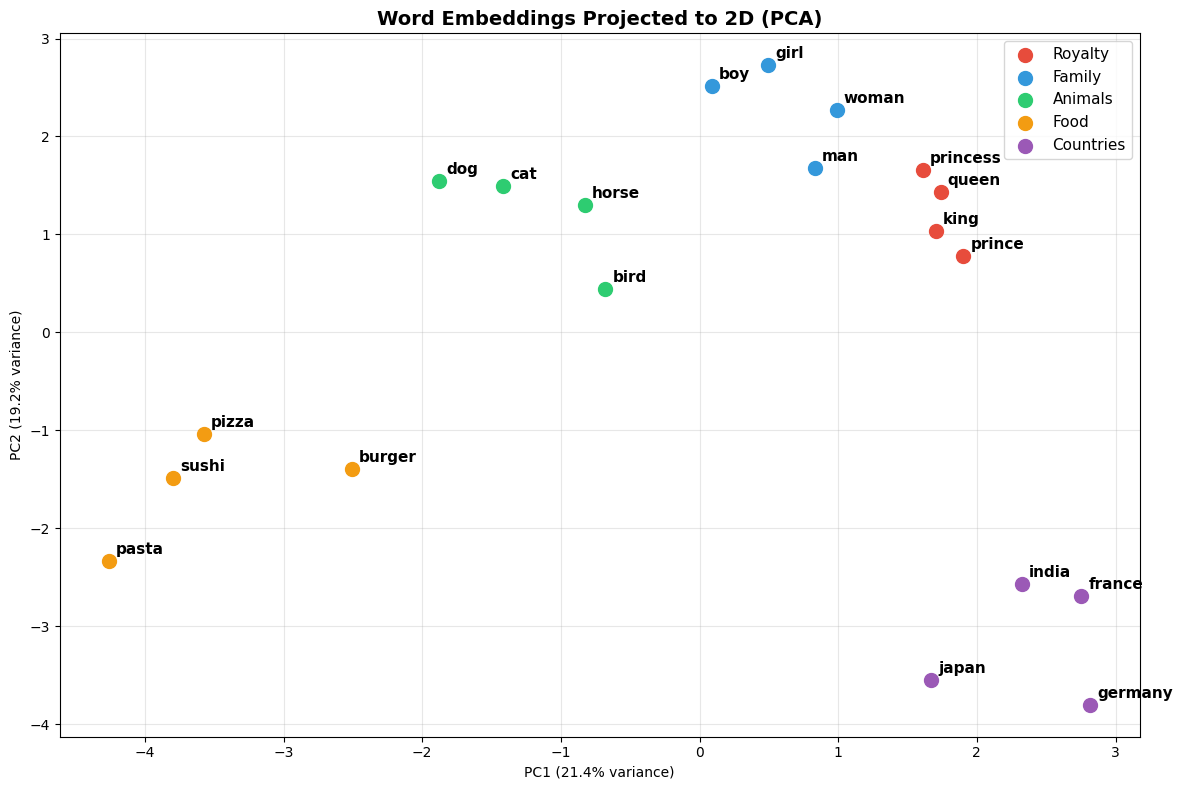

Notice how words in the same category cluster together!


In [17]:
# Words to visualize — grouped by category
word_groups = {
    "Royalty":   ["king", "queen", "prince", "princess"],
    "Family":    ["man", "woman", "boy", "girl"],
    "Animals":   ["dog", "cat", "horse", "bird"],
    "Food":      ["pizza", "burger", "pasta", "sushi"],
    "Countries": ["france", "germany", "japan", "india"],
}

# Assign colors to each group
colors = ["#e74c3c", "#3498db", "#2ecc71", "#f39c12", "#9b59b6"]

# Get all words and their vectors
all_words = []
all_vectors = []
word_colors = []
word_group_labels = []

for (group_name, words), color in zip(word_groups.items(), colors):
    for word in words:
        all_words.append(word)
        all_vectors.append(glove[word])
        word_colors.append(color)
        word_group_labels.append(group_name)

# Reduce from 100D to 2D using PCA
pca = PCA(n_components=2)
coords = pca.fit_transform(np.array(all_vectors))

# Plot!
plt.figure(figsize=(12, 8))

for i, (word, (x, y)) in enumerate(zip(all_words, coords)):
    plt.scatter(x, y, c=word_colors[i], s=100, zorder=2)
    plt.annotate(word, (x, y), fontsize=11, fontweight='bold',
                 xytext=(5, 5), textcoords='offset points')

# Add legend
for group_name, color in zip(word_groups.keys(), colors):
    plt.scatter([], [], c=color, s=100, label=group_name)
plt.legend(fontsize=11, loc='best')

plt.title("Word Embeddings Projected to 2D (PCA)", fontsize=14, fontweight='bold')
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Notice how words in the same category cluster together!")

### Visualizing the King → Queen Analogy

Let's see the "King - Man + Woman = Queen" relationship visually. If word vectors capture gender as a *direction*, then the arrow from Man→Woman should be parallel to the arrow from King→Queen.

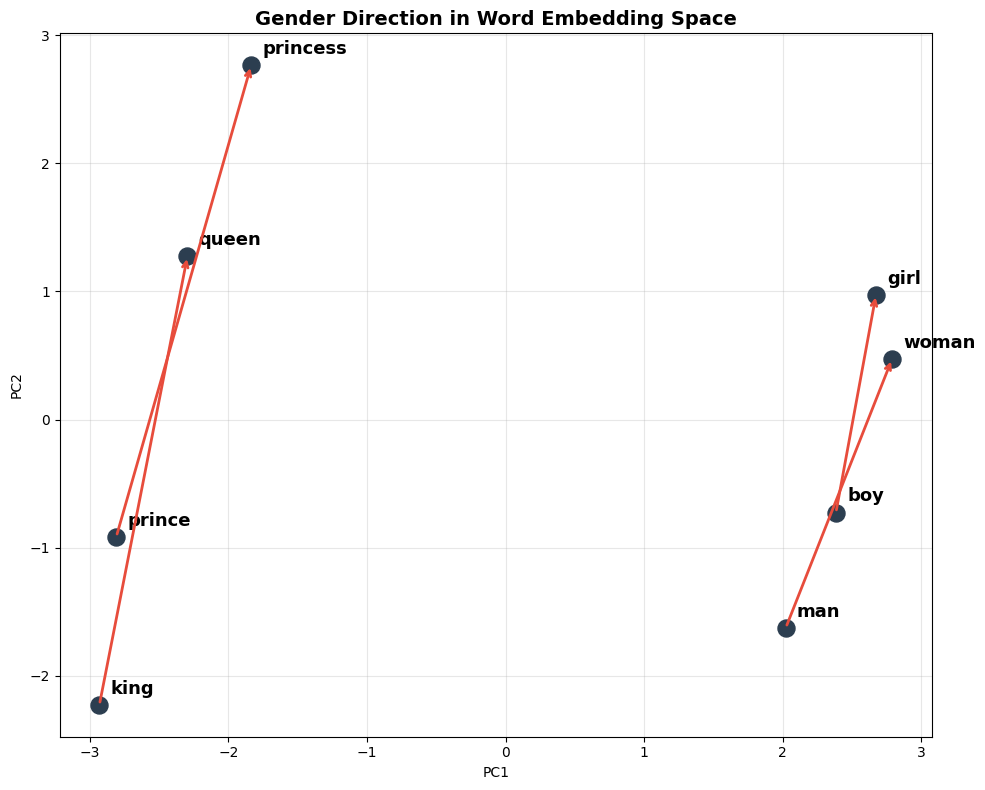

The red arrows show the 'gender direction' — notice they're roughly parallel!


In [18]:
# Visualize the king/queen/man/woman analogy
analogy_words = ["king", "queen", "man", "woman", "prince", "princess", "boy", "girl"]
analogy_vectors = [glove[w] for w in analogy_words]

pca2 = PCA(n_components=2)
coords2 = pca2.fit_transform(np.array(analogy_vectors))

plt.figure(figsize=(10, 8))

# Plot points
for word, (x, y) in zip(analogy_words, coords2):
    plt.scatter(x, y, s=150, zorder=3, c='#2c3e50')
    plt.annotate(word, (x, y), fontsize=13, fontweight='bold',
                 xytext=(8, 8), textcoords='offset points')

# Draw arrows showing the gender relationship
arrow_pairs = [("man", "woman"), ("king", "queen"), ("boy", "girl"), ("prince", "princess")]
for w1, w2 in arrow_pairs:
    i1 = analogy_words.index(w1)
    i2 = analogy_words.index(w2)
    plt.annotate("", xy=coords2[i2], xytext=coords2[i1],
                 arrowprops=dict(arrowstyle="->", color="#e74c3c", lw=2))

plt.title("Gender Direction in Word Embedding Space", fontsize=14, fontweight='bold')
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("The red arrows show the 'gender direction' — notice they're roughly parallel!")

---
## Key Takeaways

| Concept | What it means |
|---|---|
| **Bag of Words** | Counts words but misses meaning — "fever" ≠ "temperature" |
| **Word Embeddings** | Represent words as dense vectors that capture meaning |
| **Similar words → nearby vectors** | "doctor" and "nurse" are close in vector space |
| **Word arithmetic works** | king - man + woman = queen (directions encode relationships) |
| **Pre-trained vectors** | GloVe learned from billions of words — we get to use that knowledge for free! |

### Why This Matters

Word embeddings are the foundation of modern NLP. Every model you've heard of — **GPT, BERT, ChatGPT** — starts by converting words into vectors. The embeddings have gotten much more sophisticated (they now change based on context!), but the core idea is the same: **turn words into numbers that capture meaning**.